# SHD-62 Spikes and Drops

This notebook contains analysis for https://ayadev.atlassian.net/browse/SHD-62

## Load analysis dependencies and define row-counting helper

This cell imports the libraries used by the notebook, configures pandas display options, and defines a helper that counts the lines in each workload CSV.

In [471]:
from pathlib import Path
import pandas as pd
import json

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)


def count_csv_rows(workload_files):
    workload_file_line_counts = {
        path.name: sum(1 for _ in path.open("r", encoding="utf-8"))
        for path in workload_files
    }
    total_line_count = sum(n for n in workload_file_line_counts.values())
    # Includes headers
    print(f"Total number of rows: {total_line_count:,}")

## Define Helpers

This function reads each supplied CSV and concatenates the results into a single pandas DataFrame for analysis.

In [472]:
# Combine workload CSV files into one DataFrame
def read_csvs_into_df(workload_files):
    workload_df = pd.concat(
    (pd.read_csv(path, index_col=0) for path in workload_files),
    ignore_index=True,
    )
    return workload_df


# Summarize workload types, units, and facilities
# This function reports the distinct workload types, units, and facilities, including the number of unique units associated with each type.
def analyze_FTUs(workload_df):
    unique_types = workload_df["Type"].dropna().unique().tolist()
    print(f"Unique Type values: {len(unique_types)}")
    unique_units = workload_df["Unit"].dropna().unique().tolist()
    print(f"Unique Unit values: {len(unique_units)}")
    unique_facilities = workload_df["Facility"].dropna().unique().tolist()
    print(f"Unique Facility values: {len(unique_facilities)}")
    print(f"All Facilities: {unique_facilities}")
    print("Unique Types")
    print(unique_types)
    unique_facilities_by_type = workload_df.groupby("Type")["Unit"].nunique().to_dict()
    print("Unique Units per Type")
    print(unique_facilities_by_type)


# Check hourly continuity
# This helper walks through timestamped census records and identifies gaps where consecutive records are not exactly one hour apart.
def has_hourly_continuity(census_df, max_printed_gaps=5):
    previous_timestamp = None
    gaps = []

    for row in census_df.itertuples(index=False):
        if pd.isna(row.VolDate) or pd.isna(row.VolHour):
            continue

        current_timestamp = (
            pd.Timestamp(row.VolDate).normalize()
            + pd.to_timedelta(int(row.VolHour), unit="h")
        )

        if previous_timestamp is not None:
            elapsed_hours = (
                current_timestamp - previous_timestamp
            ).total_seconds() / 3600

            if elapsed_hours != 1:
                missing_hours = max(0, int(elapsed_hours - 1))

                gap = {
                    "previous": previous_timestamp,
                    "current": current_timestamp,
                    "missing_hours": missing_hours,
                }
                gaps.append(gap)

                # if len(gaps) <= max_printed_gaps:
                #     print(
                #         f"Gap from {previous_timestamp} to "
                #         f"{current_timestamp}: "
                #         f"{missing_hours} missing hour(s)"
                #     )

        previous_timestamp = current_timestamp

    return len(gaps) == 0, gaps


# Calculate facility and unit workload statistics
# These functions filter records, remove duplicates, normalize timestamps and volumes, check continuity, calculate summary statistics, and print results in a Confluence-table format.
def normalize_type_names(type_names):
    return [type_names] if isinstance(type_names, str) else list(type_names)


def analyze(workload_df, facility, unit, type_names):
    type_names = normalize_type_names(type_names)
    census_df = workload_df[
        workload_df["Type"].isin(type_names)
        & (workload_df["Facility"] == facility)
        & (workload_df["Unit"] == unit)
    ].copy()

    if census_df.empty:
        return {
            "facility": facility,
            "unit": unit,
            "timespan": "No data",
            "rows": 0,
            "contiguous": "N/A",
            "missing_rows": "N/A",
            "volume_mean": "N/A",
            "volume_mad": "N/A",
            "volume_iqr": "N/A",
            "volume_std": "N/A",
        }

    census_df = census_df.drop_duplicates().reset_index(drop=True)

    census_df["Volume"] = pd.to_numeric(census_df["Volume"])
    duplicate_key_columns = [
        column for column in census_df.columns
        if column != "Volume"
    ]

    census_df = (
        census_df
        .sort_values("Volume", ascending=False, kind="stable")
        .drop_duplicates(
            subset=duplicate_key_columns,
            keep="first",
        )
    )

    census_df["VolDate"] = pd.to_datetime(
        census_df["VolDate"],
        format="mixed",
    )
    census_df["VolHour"] = pd.to_numeric(census_df["VolHour"])

    census_df = (
        census_df
        .sort_values(["VolDate", "VolHour"])
        .reset_index(drop=True)
    )

    first_timestamp = (
        census_df["VolDate"].iloc[0].normalize()
        + pd.to_timedelta(census_df["VolHour"].iloc[0], unit="h")
    )
    last_timestamp = (
        census_df["VolDate"].iloc[-1].normalize()
        + pd.to_timedelta(census_df["VolHour"].iloc[-1], unit="h")
    )

    is_contiguous, gaps = has_hourly_continuity(census_df)

    missing_rows = sum(
        gap["missing_hours"]
        for gap in gaps
    )

    volume = census_df["Volume"]
    workload_summary = volume.agg(["mean", "std"])
    median_absolute_deviation = (
        volume - volume.median()
    ).abs().median()
    q1, q3 = volume.quantile([0.25, 0.75])
    iqr = q3 - q1

    return {
        "facility": facility,
        "unit": unit,
        "timespan": (
            f"{first_timestamp:%Y-%m-%d %H:%M} – "
            f"{last_timestamp:%Y-%m-%d %H:%M}"
        ),
        "rows": len(census_df),
        "contiguous": is_contiguous,
        "missing_rows": missing_rows,
        "volume_mean": float(workload_summary["mean"]),
        "volume_mad": float(median_absolute_deviation),
        "volume_iqr": float(iqr),
        "volume_std": float(workload_summary["std"]),
    }


def results_to_confluence_df(first_file, results):
    columns = {
        "facility": "Facility",
        "unit": "Unit name",
        "timespan": "Timespan",
        "rows": "Num rows after deduplicating",
        "contiguous": "Is it contiguous",
        "missing_rows": "Missing rows",
        "volume_mean": "Mean",
        "volume_mad": "MAD",
        "volume_iqr": "IQR",
        "volume_std": "Standard deviation",
    }
    formatted_df = pd.DataFrame(
        results,
        columns=list(columns),
    ).rename(columns=columns)
    formatted_df.insert(0, "First File", str(first_file))

    for column in ["Mean", "MAD", "IQR", "Standard deviation"]:
        formatted_df[column] = formatted_df[column].map(
            lambda value: f"{value:.2f}"
            if isinstance(value, (int, float))
            else value
        )

    return formatted_df[
        [
            "First File", "Facility", "Unit name", "Timespan",
            "Num rows after deduplicating", "Is it contiguous",
            "Missing rows", "Mean", "MAD", "IQR",
            "Standard deviation",
        ]
    ]


def print_confluence_row(confluence_df):
    for row in confluence_df.itertuples(index=False, name=None):
        escaped_row = [str(value).replace("|", "\\|") for value in row]
        print(" | " + " | ".join(escaped_row) + " |")

# Analyze one facility, type, and unit combination
# This function loads a file group, analyzes the requested facility, workload types, and unit, and returns one formatted result row for that file group.
def analyze_one_facility_type_unit(file_set, facility, type_names, unit_name):
    workload_df = read_csvs_into_df(file_set)
    type_names = normalize_type_names(type_names)
    analyze_FTUs(workload_df)
    results = [
        analyze(
            workload_df,
            facility=facility,
            unit=unit,
            type_names=type_names,
        )
        for unit in [unit_name]
    ]

    return results_to_confluence_df(file_set[0], results)

## Configure workload files and units

This cell defines the workload CSV file groups and the unit names available for the facility and type analyses.

In [473]:
# All files

all_workload_files = [
    sorted(Path("data/wellspanhealth_historical_workload_2").glob("*.csv")),
    [Path("data/WellspanHealth_Workload_EDESI_Historical2026-070320261715.csv")],
    [Path("data/WellspanHealth_Workload_YH_ED_WR_3Years_202605141133.csv")],
    [Path("data/wellspanhealth_historical_workload_11212025_1314.csv")],
    [Path("data/wellspanhealth_workload_202602251105.csv")],
    [Path("data/WellspanHealth_Workload_Historical_ESI_Census_202605121512.csv")],
]

all_units = [
    "ESI4 - 1100-32327 YH Emerg Dept - General",
    "ESI3 - 1100-32327 YH Emerg Dept - General",
    "ESI1 - 1100-32327 YH Emerg Dept - General",
    "ESI5 - 1100-32327 YH Emerg Dept - General",
    "WR - 1100-32327 YH Emerg Dept - General",
    "1100-23603 YH Med Unts - 4 Main",
    "1100-23604 YH Med Unts - 4 Southwest",
    "1100-26003 YH Progress Care IMCU - 4 Southwest Med",
    "1100-23607 YH Med Unts - 5 East",
    "1100-23602 YH Med Unts - 5 Main",
    "1100-23601 YH Med Unts - 5 South",
    "1100-26901 YH Surg Unts - 6 Main Nursing Unit",
    "1100-26900 YH Surg Unts - 6 South Nursing Unit",
    "1100-24500 YH Onco Unts - Nursing Unt 7S",
    "1100-50000 YH Adult Psych Unts - InPtnt Pgm - 4301",
    "1100-26602 YH Spec ICU - Cardiac Intens Care Unt ICU",
    "1100-32327 YH Emerg Dept - General",
    "1100-32326 YH Emerg Dept - Emerg Transitional Care Unit",
    "1100-23300 YH Womens Svcs LDRPN GYN - Labor and Delivery",
    "1100-21501 YH ICU - Med",
    "1100-23605 YH Med Unts - N3A",
    "1100-23000 YH Mother Baby Unts - Maternity Newborn Unit",
    "1100-22700 YH Level III - Neonatal Intens Care Nursry - General",
    "1100-26600 YH Spec ICU - Neuroscience",
    "1100-26601 YH Spec ICU - O H Intens Care Unt ICU",
    "1100-25700 YH Pediatric Unts - General",
    "1100-21500 YH ICU - Surg",
    "1100-20600 YH Coronary Care Unts - T2 - Cardio",
    "1100-26002 YH Progress Care IMCU - T2",
    "1100-24801 YH Ortho Neuro Surg -T3",
    "1100-26603 YH Spec ICU - Trauma Surg Intens Care Unt ICU",
    "1100-23603 YH Med Unts - 4 Main",
    "1100-23604 YH Med Unts - 4 Southwest",
    "1100-23607 YH Med Unts - 5 East",
    "1100-23602 YH Med Unts - 5 Main",
    "1100-23601 YH Med Unts - 5 South",
    "1100-26901 YH Surg Unts - 6 Main Nursing Unit",
    "1100-26900 YH Surg Unts - 6 South Nursing Unit",
    "1100-24500 YH Onco Unts - Nursing Unt 7S",
    "1100-50000 YH Adult Psych Unts - InPtnt Pgm - 4301",
    "1100-26602 YH Spec ICU - Cardiac Intens Care Unt ICU",
    "1100-32327 YH Emerg Dept - General",
    "1100-32326 YH Emerg Dept - Emerg Transitional Care Unit",
    "1100-23300 YH Womens Svcs LDRPN GYN - Labor and Delivery",
    "1100-21501 YH ICU - Med",
    "1100-23605 YH Med Unts - N3A",
    "1100-23000 YH Mother Baby Unts - Maternity Newborn Unit",
    "1100-22700 YH Level III - Neonatal Intens Care Nursry - General",
    "1100-26600 YH Spec ICU - Neuroscience",
    "1100-26601 YH Spec ICU - O H Intens Care Unt ICU",
    "1100-25700 YH Pediatric Unts - General",
    "1100-21500 YH ICU - Surg",
    "1100-20600 YH Coronary Care Unts - T2 - Cardio",
    "1100-24801 YH Ortho Neuro Surg -T3",
    "1100-26603 YH Spec ICU - Trauma Surg Intens Care Unt ICU",
    "1100-26002 YH Progress Care IMCU - T2",
    "1100-26003 YH Progress Care IMCU - 4 Southwest Med",
    "1100-32327 YH Emerg Dept - General",
    "1100-23603 YH Med Unts - 4 Main",
    "1100-22700 YH Level III - Neonatal Intens Care Nursry - General",
    "1100-23604 YH Med Unts - 4 Southwest",
    "1100-24500 YH Onco Unts - Nursing Unt 7S",
    "1100-26900 YH Surg Unts - 6 South Nursing Unit",
    "1100-25700 YH Pediatric Unts - General",
    "1100-23605 YH Med Unts - N3A",
    "1100-26602 YH Spec ICU - Cardiac Intens Care Unt ICU",
    "1100-26601 YH Spec ICU - O H Intens Care Unt ICU",
    "1100-23601 YH Med Unts - 5 South",
    "1100-21501 YH ICU - Med",
    "1100-26600 YH Spec ICU - Neuroscience",
    "1100-21500 YH ICU - Surg",
    "1100-26603 YH Spec ICU - Trauma Surg Intens Care Unt ICU",
    "1100-23300 YH Womens Svcs LDRPN GYN - Labor and Delivery",
    "1100-20600 YH Coronary Care Unts - T2 - Cardio",
    "1100-24801 YH Ortho Neuro Surg -T3",
    "1100-23000 YH Mother Baby Unts - Maternity Newborn Unit",
    "1100-50000 YH Adult Psych Unts - InPtnt Pgm - 4301",
    "1100-30526 YH Cardiac Cath EP Lab - Cardiac Cath Lab",
    "1100-23602 YH Med Unts - 5 Main",
    "1100-15001 YH Oper Room - Advanced Procedural Suite",
    "1100-18000 YH Short Stay Surg - General",
    "1100-17000 YH Post Anesth Care Unts",
    "1100-13000 YH Gastro Endo - Endoscopy",
    "1100-23607 YH Med Unts - 5 East",
    "1100-32100 YH Dialysis - General",
    "1100-26002 YH Progress Care IMCU - T2",
    "1100-26003 YH Progress Care IMCU - 4 Southwest Med",
    "1100-32327 YH Emerg Dept - General",
]


## Run the initial workload comparison

This cell selects the York Hospital emergency-department census series and runs the analysis across every configured workload file group.

In [ ]:
# 3 year coverage
facility = "1100-York Hospital"
type_names = ["Census"]
unit_name = "1100-32327 YH Emerg Dept - General"

# 3 year coverage
# facility = "1100-York Hospital"
# type_names = [
# 'CENSUS - ESI1',
# 'CENSUS - ESI2',
# 'CENSUS - ESI3',
# 'CENSUS - ESI4',
# 'CENSUS - ESI5'
# ]
# unit_name = "1100-32327 YH Emerg Dept - General"



summary_df = pd.concat(
    [
        analyze_one_facility_type_unit(
            file_set, facility, type_names, unit_name
        )
        for file_set in all_workload_files
    ],
    ignore_index=True,
)
display(summary_df)

# print_confluence_row(summary_df)

Unique Type values: 4
Unique Unit values: 26
Unique Facility values: 1
All Facilities: ['1100-York Hospital']
Unique Types
['Census', 'Census - NURSERY', 'Census - POSTPARTUM', 'Census - T4 FLEX']
Unique Units per Type
{'Census': 25, 'Census - NURSERY': 1, 'Census - POSTPARTUM': 1, 'Census - T4 FLEX': 1}
Unique Type values: 5
Unique Unit values: 7
Unique Facility values: 7
All Facilities: ['1000-Ephrata Community Hospital', '1201-Gettysburg Hospital', '1100-York Hospital', '1001-The Good Samaritan Hospital', '1202-Waynesboro Hospital', '1200-Chambersburg Hospital', '1375-North ACO - Specialty Care Physician Services']
Unique Types
['CENSUS - ESI1', 'CENSUS - ESI2', 'CENSUS - ESI3', 'CENSUS - ESI4', 'CENSUS - ESI5']
Unique Units per Type
{'CENSUS - ESI1': 7, 'CENSUS - ESI2': 7, 'CENSUS - ESI3': 7, 'CENSUS - ESI4': 7, 'CENSUS - ESI5': 7}
Unique Type values: 1
Unique Unit values: 1
Unique Facility values: 1
All Facilities: ['1100-York Hospital']
Unique Types
['Census']
Unique Units per Ty

/var/folders/km/gzfmffxn3219fbtl84mfnhq00000gn/T/ipykernel_7635/1475280940.py:4: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  (pd.read_csv(path, index_col=0) for path in workload_files),


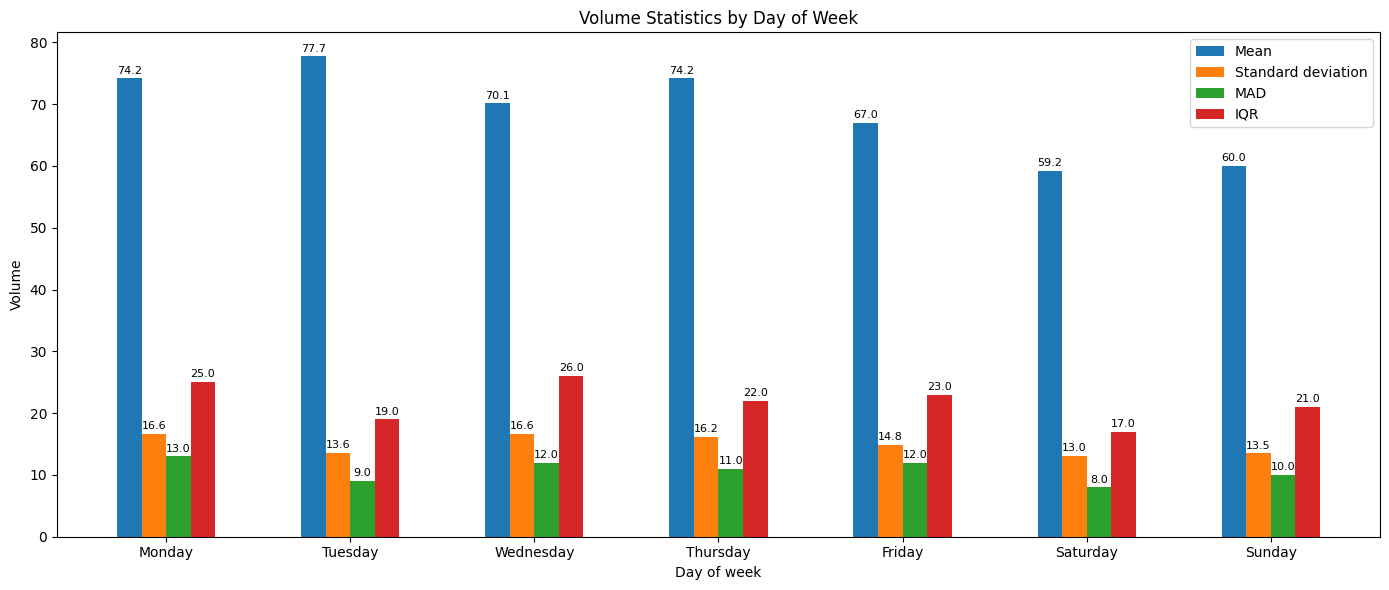

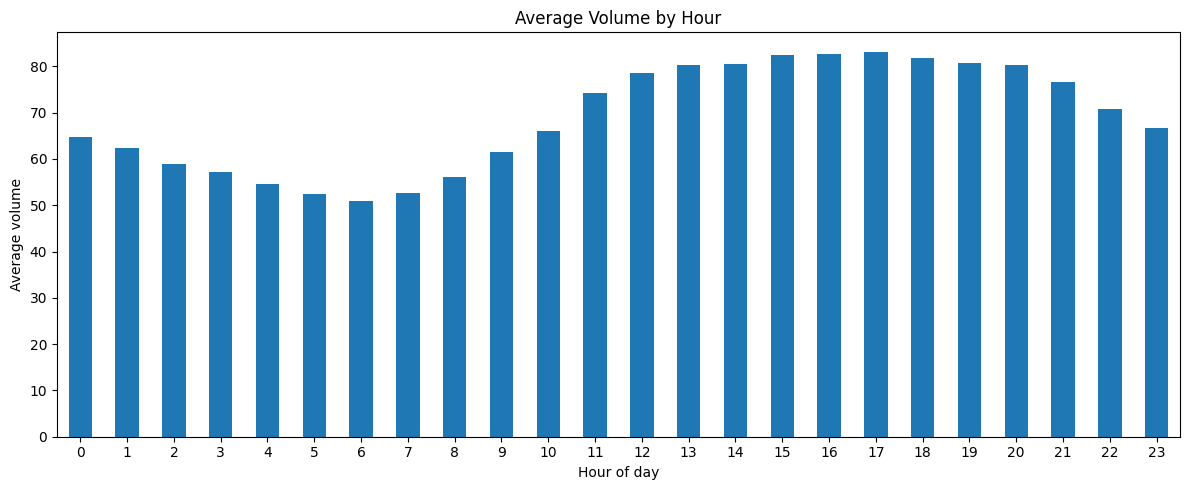

In [ ]:
# Seasonality Analysis
import matplotlib.pyplot as plt
import numpy as np
from pandas.tseries.holiday import USFederalHolidayCalendar

weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

seasonality_df = pd.concat(
    (read_csvs_into_df(file_set) for file_set in all_workload_files),
    ignore_index=True,
)
seasonality_df = seasonality_df[
    seasonality_df["Type"].isin(type_names)
    & (seasonality_df["Facility"] == facility)
    & (seasonality_df["Unit"] == unit_name)
].copy()
seasonality_df["Volume"] = pd.to_numeric(
    seasonality_df["Volume"],
    errors="coerce",
)
seasonality_df["VolDate"] = pd.to_datetime(
    seasonality_df["VolDate"],
    format="mixed",
)
seasonality_df["VolHour"] = pd.to_numeric(
    seasonality_df["VolHour"],
    errors="coerce",
)

weekday_volume_statistics = (
    seasonality_df.assign(
        day_of_week=seasonality_df["VolDate"].dt.day_name()
    )
    .groupby("day_of_week")["Volume"]
    .agg(
        mean="mean",
        standard_deviation="std",
        mad=lambda values: (values - values.median()).abs().median(),
        iqr=lambda values: values.quantile(0.75) - values.quantile(0.25),
    )
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(14, 6))
bar_width = 0.18
group_positions = np.arange(len(weekday_order)) * 1.35
metric_offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * bar_width
metric_columns = [
    "mean",
    "standard_deviation",
    "mad",
    "iqr",
]
metric_labels = [
    "Mean",
    "Standard deviation",
    "MAD",
    "IQR",
]

for offset, column, label in zip(
    metric_offsets, metric_columns, metric_labels
):
    bars = ax.bar(
        group_positions + offset,
        weekday_volume_statistics[column],
        width=bar_width,
        label=label,
    )
    ax.bar_label(bars, fmt="%.1f", padding=2, fontsize=8)

ax.set_title("Volume Statistics by Day of Week")
ax.set_xlabel("Day of week")
ax.set_ylabel("Volume")
ax.set_xticks(group_positions, weekday_order)
ax.legend()
plt.tight_layout()
plt.show()

quarter_order = ["Q1", "Q2", "Q3", "Q4"]
quarterly_volume = seasonality_df.assign(
    quarter="Q" + seasonality_df["VolDate"].dt.quarter.astype(str)
)
quarterly_data = [
    quarterly_volume.loc[
        quarterly_volume["quarter"] == quarter,
        "Volume",
    ].dropna()
    for quarter in quarter_order
]
quarterly_means = [values.mean() for values in quarterly_data]

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(
    quarterly_data,
    labels=quarter_order,
    showmeans=True,
    meanprops={"marker": "D", "markerfacecolor": "red", "markeredgecolor": "red"},
)
ax.set_title("Volume Distribution by Quarter")
ax.set_xlabel("Quarter")
ax.set_ylabel("Volume")
ax.text(
    0.98,
    0.98,
    "Red diamond = mean",
    transform=ax.transAxes,
    ha="right",
    va="top",
    color="red",
)
plt.tight_layout()
plt.show()

average_volume_by_hour = (
    seasonality_df.groupby("VolHour")["Volume"]
    .mean()
    .reindex(range(24))
)

average_volume_by_hour.plot(
    kind="bar",
    figsize=(12, 5),
    title="Average Volume by Hour",
    xlabel="Hour of day",
    ylabel="Average volume",
    rot=0,
)
plt.tight_layout()
plt.show()

seasonality_df["record_date"] = seasonality_df["VolDate"].dt.normalize()
holiday_calendar = USFederalHolidayCalendar()
holiday_dates = holiday_calendar.holidays(
    start=seasonality_df["record_date"].min(),
    end=seasonality_df["record_date"].max(),
    return_name=True,
)

holiday_event_rows = []
for holiday_date, holiday_name in holiday_dates.items():
    for relative_day in range(-3, 4):
        event_date = holiday_date + pd.Timedelta(days=relative_day)
        event_volume = seasonality_df.loc[
            seasonality_df["record_date"] == event_date,
            "Volume",
        ].dropna()
        if not event_volume.empty:
            holiday_event_rows.append(
                {
                    "holiday_name": holiday_name,
                    "relative_day": relative_day,
                    "average_volume": event_volume.mean(),
                }
            )

holiday_event_df = pd.DataFrame(holiday_event_rows)
fig, ax = plt.subplots(figsize=(12, 6))
for holiday_name, holiday_group in holiday_event_df.groupby("holiday_name"):
    ax.plot(
        holiday_group["relative_day"],
        holiday_group["average_volume"],
        marker="o",
        label=holiday_name,
    )
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.axhline(
    seasonality_df.loc[
        ~seasonality_df["record_date"].isin(holiday_dates.index),
        "Volume",
    ].mean(),
    color="gray",
    linestyle=":",
    label="Non-holiday average",
)
ax.set_title("Volume Around U.S. Federal Holidays")
ax.set_xlabel("Days relative to holiday")
ax.set_ylabel("Average volume")
ax.set_xticks(range(-3, 4))
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

quarter_hour_average = (
    seasonality_df.assign(
        quarter="Q" + seasonality_df["VolDate"].dt.quarter.astype(str)
    )
    .groupby(["quarter", "VolHour"])["Volume"]
    .mean()
    .unstack()
    .reindex(index=quarter_order, columns=range(24))
)

fig, ax = plt.subplots(figsize=(13, 5))
heatmap = ax.imshow(quarter_hour_average, aspect="auto", cmap="YlOrRd")
ax.set_title("Average Volume by Quarter and Hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("Quarter")
ax.set_xticks(range(24), range(24), rotation=45)
ax.set_yticks(range(len(quarter_order)), quarter_order)
fig.colorbar(heatmap, ax=ax, label="Average volume")
plt.tight_layout()
plt.show()